=== ANÁLISIS EXPLORATORIO DE DATOS (EDA) ===
El dataset está compuesto por 6 registros (viajes) y 22 variables predictoras.



,snapshot_id,operator_name,bus_type,source_city,destination_city,departure_time,is_synthetic,min_fare,lead_time_hours,total_seats,...,is_holiday,holiday_proximity,days_to_payday,temp_max,temp_min,precipitation,usd_pen,wti_price,fuel_local_proxy,occupied_seats_proxy
0,1,Turismo Cautivo,MASTER,Lima,Chiclayo,2026-09-07 17:00:00,False,70.0,71.33,63,...,False,0.0,8,28.0,21.9,0.0,3.354,91.48,306.82,23
1,2,Turismo Cautivo,MASTER,Lima,Chiclayo,2026-09-07 17:00:00,False,70.0,69.96,63,...,False,0.0,8,28.0,21.9,0.0,3.354,91.48,306.82,23
2,3,Transportes Chiclayo,BUS CAMA,Lima,Chiclayo,2026-09-07 18:30:00,False,70.0,71.46,62,...,False,0.0,8,28.0,21.9,0.0,3.354,91.48,306.82,15


C:\Users\SUPER-PC\AppData\Local\Temp\ipykernel_31592\503987040.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='bus_type', y='occupied_seats_proxy', palette='viridis')


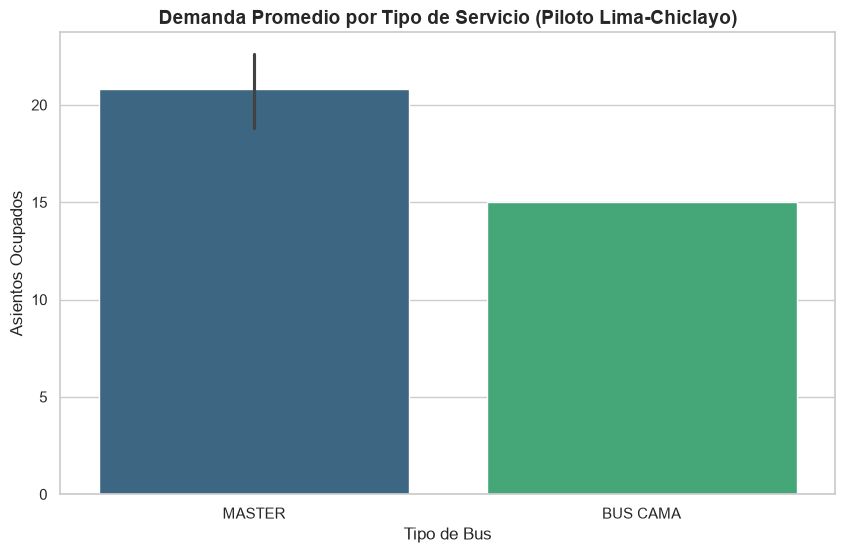

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 1. Cargar las credenciales y conectar a Supabase
load_dotenv('../.env')
db_url = os.getenv("DATABASE_URL")
engine = create_engine(db_url)

# 2. Descargar la vista maestra completa
query = "SELECT * FROM analytics.vw_demand_features;"
df = pd.read_sql(query, engine)

# 3. Configurar el estilo visual de los gráficos (Estilo profesional para tesis)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 4. Mostrar información general
print("=== ANÁLISIS EXPLORATORIO DE DATOS (EDA) ===")
print(f"El dataset está compuesto por {df.shape[0]} registros (viajes) y {df.shape[1]} variables predictoras.\n")

# Mostrar las primeras 3 filas para confirmar que todo llegó
display(df.head(3))

# 5. Generar el Primer Gráfico: Ocupación según Tipo de Bus
plt.figure()
sns.barplot(data=df, x='bus_type', y='occupied_seats_proxy', palette='viridis')
plt.title('Demanda Promedio por Tipo de Servicio (Piloto Lima-Chiclayo)', fontsize=14, fontweight='bold')
plt.ylabel('Asientos Ocupados', fontsize=12)
plt.xlabel('Tipo de Bus', fontsize=12)

# Mostrar el gráfico
plt.show()